# Import

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("ssmproject.csv")
df

,Timestamp,Grade,CanteenVisit,EatFreq,TimeOfDay,GroupSize,AvgSpend,FoodCat,MainReason,FoodQuality,FoodPrice,Cleanliness,QueueSys,QueueTime,Ambience,SeatComfort,AirCirc,OutOfStock,CantHours
0,15/05/2025 14:46,B27,Beberapa kali dalam satu minggu,3,Siang,4,Rp 26.000 - Rp 30.000,Bakmie,Rasa makanan,5,4,4,4,4,4,4,4,5,3
1,15/05/2025 14:47,B26,Jarang atau tidak pernah,2,Siang,2,> Rp 30.000,Makanan berbasis nasi,Variasi makanan,4,4,4,4,4,4,4,5,2,3
2,15/05/2025 14:50,B27,Beberapa kali dalam satu minggu,3,Siang,4,Rp 26.000 - Rp 30.000,Makanan berbasis nasi,Variasi makanan,4,3,5,2,3,4,4,4,3,2
3,15/05/2025 14:52,B27,Beberapa kali dalam satu minggu,1,Siang,4,Rp 21.000 - Rp 25.000,Makanan berbasis nasi,Rasa makanan,4,4,4,2,3,4,4,3,2,4
4,15/05/2025 14:55,B27,Jarang atau tidak pernah,1,Siang,2,Rp 21.000 - Rp 25.000,Makanan berbasis nasi,Rasa makanan,4,3,3,2,3,3,5,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,28/05/2025 17:52,B27,Beberapa kali dalam satu minggu,3,Pagi,2,Rp 16.000 - Rp 20.000,Makanan berbasis mie/kwetiau/bihun/dsb.,Fasilitas,4,3,5,5,5,5,5,5,5,5
161,28/05/2025 17:53,B27,Beberapa kali dalam satu minggu,4,Sore,5,> Rp 30.000,Makanan berbasis mie/kwetiau/bihun/dsb.,Lokasi,3,3,3,3,4,4,4,4,4,4
162,28/05/2025 17:54,B27,Sehari sekali,3,Pagi,3,> Rp 30.000,Cemilan ringan,Fasilitas,4,4,4,4,4,4,4,4,4,4
163,29/05/2025 03:10,B27,Beberapa kali dalam sehari,6,Siang,4,> Rp 30.000,Makanan berbasis nasi,Lokasi,3,3,3,2,2,3,3,3,2,2


# Select Grade

Ambil hanya dari B27, remove angkatan lainnya

In [6]:
df = df[df["Grade"] == "B27"]
df

,Timestamp,Grade,CanteenVisit,EatFreq,TimeOfDay,GroupSize,AvgSpend,FoodCat,MainReason,FoodQuality,FoodPrice,Cleanliness,QueueSys,QueueTime,Ambience,SeatComfort,AirCirc,OutOfStock,CantHours
0,15/05/2025 14:46,B27,Beberapa kali dalam satu minggu,3,Siang,4,Rp 26.000 - Rp 30.000,Bakmie,Rasa makanan,5,4,4,4,4,4,4,4,5,3
2,15/05/2025 14:50,B27,Beberapa kali dalam satu minggu,3,Siang,4,Rp 26.000 - Rp 30.000,Makanan berbasis nasi,Variasi makanan,4,3,5,2,3,4,4,4,3,2
3,15/05/2025 14:52,B27,Beberapa kali dalam satu minggu,1,Siang,4,Rp 21.000 - Rp 25.000,Makanan berbasis nasi,Rasa makanan,4,4,4,2,3,4,4,3,2,4
4,15/05/2025 14:55,B27,Jarang atau tidak pernah,1,Siang,2,Rp 21.000 - Rp 25.000,Makanan berbasis nasi,Rasa makanan,4,3,3,2,3,3,5,1,1,5
5,15/05/2025 14:56,B27,Beberapa kali dalam satu minggu,3,Siang,3,Rp 21.000 - Rp 25.000,Makanan berbasis nasi,Fasilitas,4,4,4,3,3,4,5,2,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,28/05/2025 17:52,B27,Beberapa kali dalam satu minggu,3,Pagi,2,Rp 16.000 - Rp 20.000,Makanan berbasis mie/kwetiau/bihun/dsb.,Fasilitas,4,3,5,5,5,5,5,5,5,5
161,28/05/2025 17:53,B27,Beberapa kali dalam satu minggu,4,Sore,5,> Rp 30.000,Makanan berbasis mie/kwetiau/bihun/dsb.,Lokasi,3,3,3,3,4,4,4,4,4,4
162,28/05/2025 17:54,B27,Sehari sekali,3,Pagi,3,> Rp 30.000,Cemilan ringan,Fasilitas,4,4,4,4,4,4,4,4,4,4
163,29/05/2025 03:10,B27,Beberapa kali dalam sehari,6,Siang,4,> Rp 30.000,Makanan berbasis nasi,Lokasi,3,3,3,2,2,3,3,3,2,2


In [7]:
df = df.drop(columns = "Grade")

# 5a. Validity

In [9]:
from scipy.stats import pearsonr

def calculate_validity(df, vars_list):
    validity_results = {}
    for var in vars_list:
        other_vars = [v for v in vars_list if v != var]
        total_score = df[other_vars].sum(axis=1)
        
        corr, _ = pearsonr(df[var], total_score)
        validity_results[var] = corr
    return validity_results

Variabel-variabel likert yang digunakan adalah FoodQuality, FoodPrice, Cleanliness, QueueSystem, dan Ambience karena kelima faktor ini dapat dikatakan paling berpengaruh saat memilih tempat makan.

Berdasarkan perhitungan validitas tersebut, kelima variabel dapat dikatakan valid karena memiliki nilai di atas 0.3. Bahkan, Ambience mendapatkan nilai 0.6, yang dapat dikatakan sangat tinggi.

In [17]:
likert_vars = ["FoodQuality", "FoodPrice", "Cleanliness", "QueueSys", "QueueTime"]
mix_vars = ["EatFreq", "GroupSize", "Ambience", "SeatComfort", "AirCirc"]

likVal = calculate_validity(df, likert_vars)
mixVal = calculate_validity(df, mix_vars)

for var, corr in likVal.items():
    print(f"{var}: {corr:.3f}")

print("\n")

for var, corr in mixVal.items():
    print(f"{var}: {corr:.3f}")

FoodQuality: 0.565
FoodPrice: 0.687
Cleanliness: 0.559
QueueSys: 0.702
QueueTime: 0.641


EatFreq: 0.201
GroupSize: 0.250
Ambience: 0.354
SeatComfort: 0.314
AirCirc: 0.358


# 5b. Reliability

In [19]:
def cronbach_alpha(df_subset):
    items = df_subset.to_numpy()
    item_variances = items.var(axis=0, ddof=1)
    total_score = items.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    k = df_subset.shape[1]
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha

In [21]:
alpha1 = cronbach_alpha(df[likert_vars])
print(f"Cronbach's Alpha: {alpha1:.3f}")

Cronbach's Alpha: 0.830


Reliability dengan Cronbach's Alpha mengembalikan nilai 0.783, menunjukkan bahwa kelima variabel dapat dikatakan konsisten secara internal. Nilai 0.7 secara umum digunakan sebagai ambang batas standar reliabilitas dalam penelitian sosial, sehingga variabel-variabel dapat dilakukan ke depannya.

In [23]:
alpha2 = cronbach_alpha(df[mix_vars])
print(f"Cronbach's Alpha: {alpha2:.3f}")

Cronbach's Alpha: 0.484


# 5c. Response Bias

In [25]:
true_mean = df['GroupSize'].mean()

# Example: mean of first 30 respondents (early responders)
early_responders_mean = df.iloc[:80]['GroupSize'].mean()

# Calculate bias
response_bias = early_responders_mean - true_mean

print(f"True Mean (Overall): {true_mean:.3f}")
print(f"Early Responders Mean: {early_responders_mean:.3f}")
print(f"Response Bias: {response_bias:.3f}")


True Mean (Overall): 3.294
Early Responders Mean: 3.062
Response Bias: -0.232


# 6ai. Missing Values

In [27]:
df.isna().sum()

Timestamp       0
CanteenVisit    0
EatFreq         0
TimeOfDay       0
GroupSize       0
AvgSpend        0
FoodCat         0
MainReason      0
FoodQuality     0
FoodPrice       0
Cleanliness     0
QueueSys        0
QueueTime       0
Ambience        0
SeatComfort     0
AirCirc         0
OutOfStock      0
CantHours       0
dtype: int64

In [29]:
df.duplicated().sum()

0

In [31]:
df = df.drop(columns = ['Timestamp'])

In [33]:
df.duplicated().sum()

0

# 6aii Summary statistics

## Categorical

In [35]:
cat_col = ["CanteenVisit", "TimeOfDay", "AvgSpend", "FoodCat", "MainReason"]

In [37]:
def display_categorical_variables(df, cat_col):
    for col in cat_col:
        if col in df.columns:
            print(f"\n--- Column: {col} ---")
            print(df[col].value_counts())
            print(f"Number of unique values: {df[col].nunique()}")
        else:
            print(f"\n--- Warning: Column '{col}' not found in the DataFrame. ---")


CanteenVisit
Beberapa kali dalam satu minggu    78
Sehari sekali                      44
Jarang atau tidak pernah           19
Beberapa kali dalam sehari         12
Name: count, dtype: int64 

TimeOfDay
Siang    113
Sore      23
Pagi      17
Name: count, dtype: int64 

AvgSpend
Rp 26.000 - Rp 30.000    51
Rp 21.000 - Rp 25.000    49
> Rp 30.000              44
Rp 16.000 - Rp 20.000     6
≤ Rp 15.000               3
Name: count, dtype: int64 

FoodCat
Makanan berbasis nasi                      79
Makanan berbasis mie/kwetiau/bihun/dsb.    40
Makanan cepat saji                         23
Cemilan ringan                              7
Minuman                                     3
Bakmie                                      1
Name: count, dtype: int64 

MainReason
Variasi makanan    51
Lokasi             50
Rasa makanan       33
Fasilitas          18
kalo kepepet        1
Name: count, dtype: int64 



## Numerical

In [39]:
num_col = ["GroupSize", "EatFreq"]

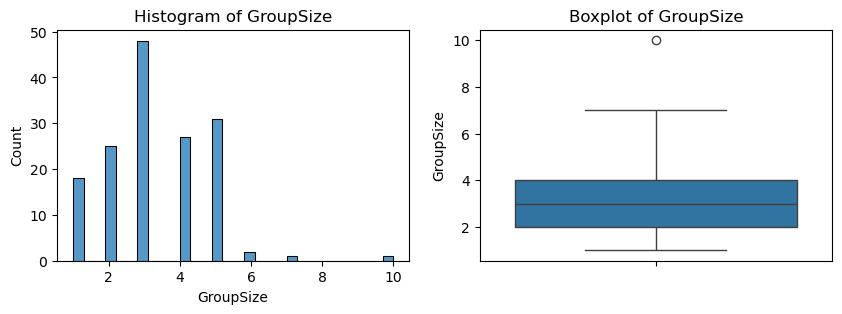

Skewness of GroupSize: 0.623511585097209
Kurtosis of GroupSize: 1.8824654302418273


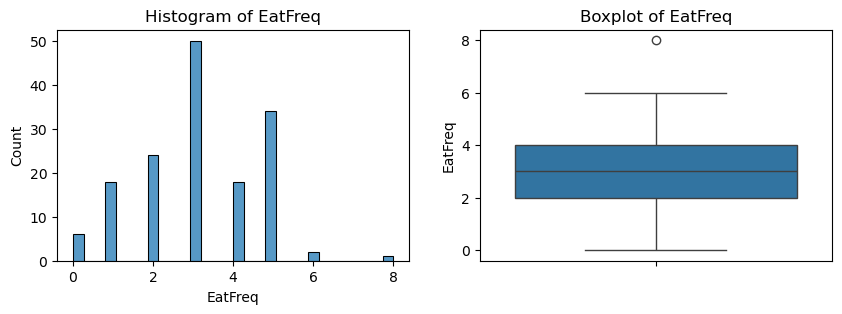

Skewness of EatFreq: 0.02013301357938623
Kurtosis of EatFreq: -0.2512890479865528


In [45]:
import seaborn as sns
from matplotlib import pyplot as plt

def check_distribution_outliers(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 2, 1)
        sns.histplot(df[col], bins=30)
        plt.title(f'Histogram of {col}')

        plt.subplot(1, 2, 2)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col}')

        plt.show()

        print(f'Skewness of {col}:', df[col].skew())
        print(f'Kurtosis of {col}:', df[col].kurt())

check_distribution_outliers(df[num_col], num_col)

## Likert

In [47]:
lik_col = ["FoodQuality","FoodPrice","Cleanliness","QueueSys","QueueTime","Ambience","SeatComfort","AirCirc","OutOfStock","CantHours"]

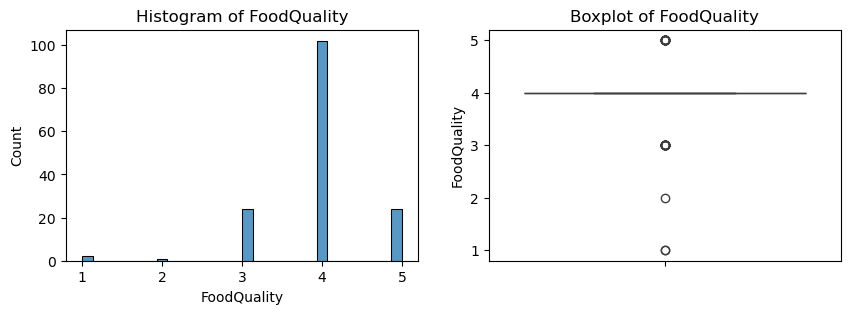

Skewness of FoodQuality: -1.0990135542209376
Kurtosis of FoodQuality: 3.934604184876686


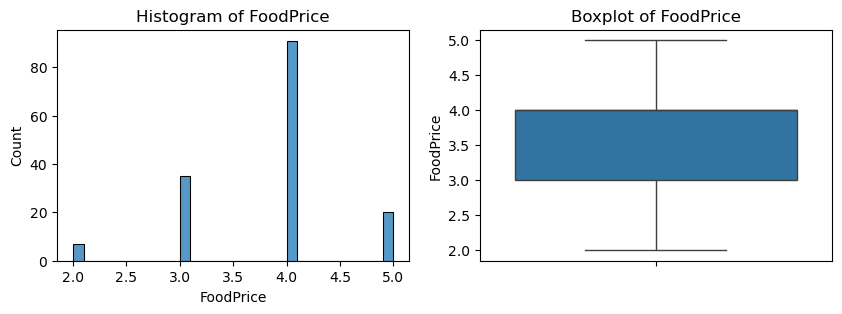

Skewness of FoodPrice: -0.4739678500876028
Kurtosis of FoodPrice: 0.37429429058630603


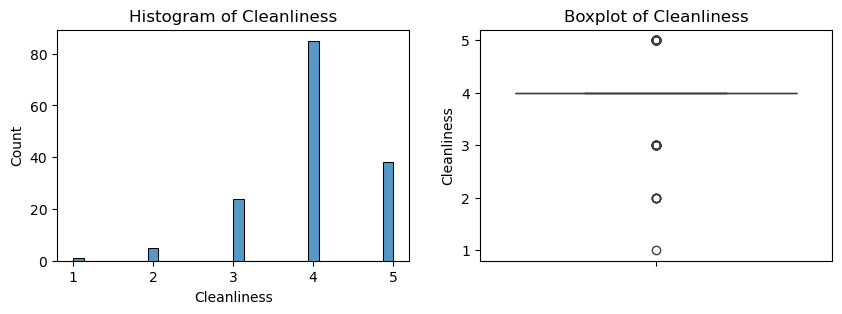

Skewness of Cleanliness: -0.7884543035283015
Kurtosis of Cleanliness: 1.2254247782912207


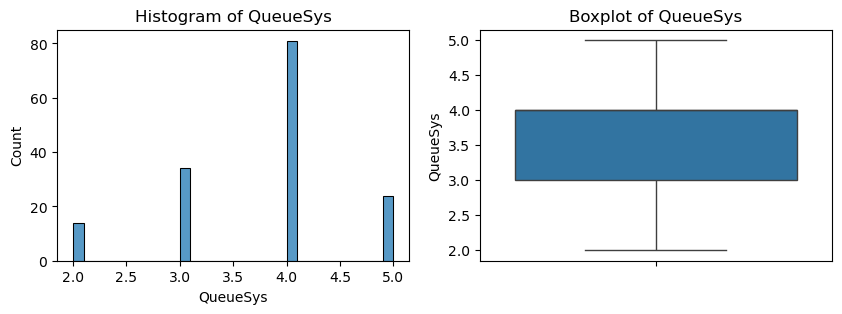

Skewness of QueueSys: -0.4877524731111686
Kurtosis of QueueSys: -0.14967268998949068


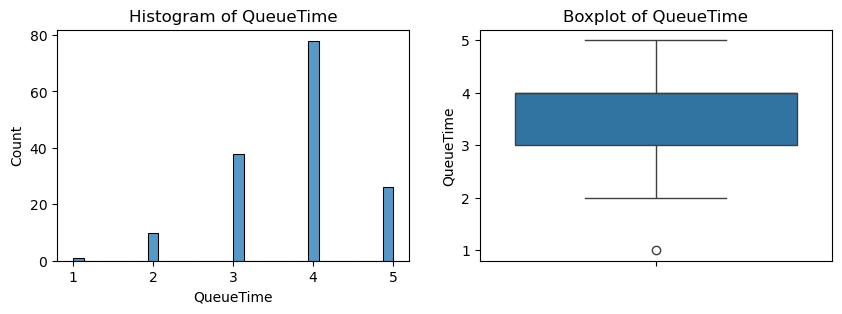

Skewness of QueueTime: -0.523847881610427
Kurtosis of QueueTime: 0.2437245744732741


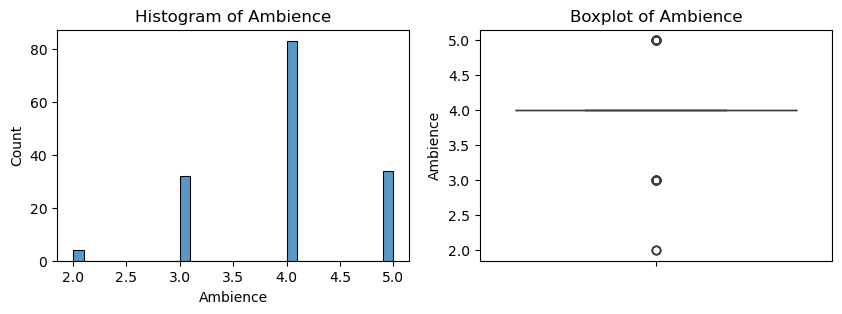

Skewness of Ambience: -0.3441979204706177
Kurtosis of Ambience: -0.07888882062580826


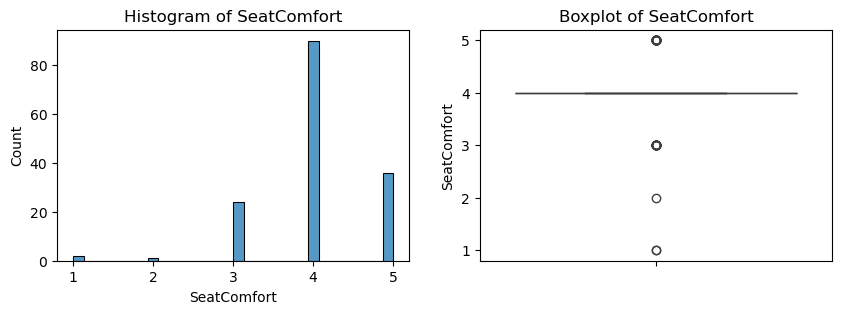

Skewness of SeatComfort: -0.9510981725888344
Kurtosis of SeatComfort: 2.6821271312356196


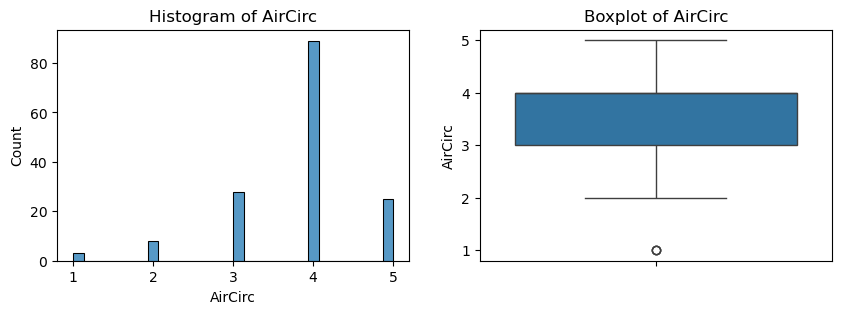

Skewness of AirCirc: -0.9993031443302519
Kurtosis of AirCirc: 1.61396022468942


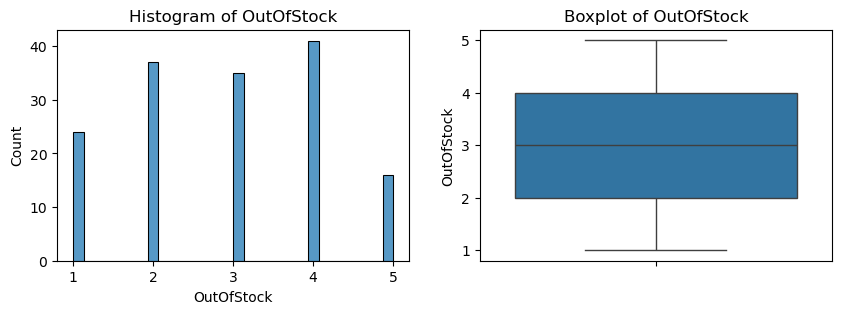

Skewness of OutOfStock: -0.014195564781199288
Kurtosis of OutOfStock: -1.0682035602780142


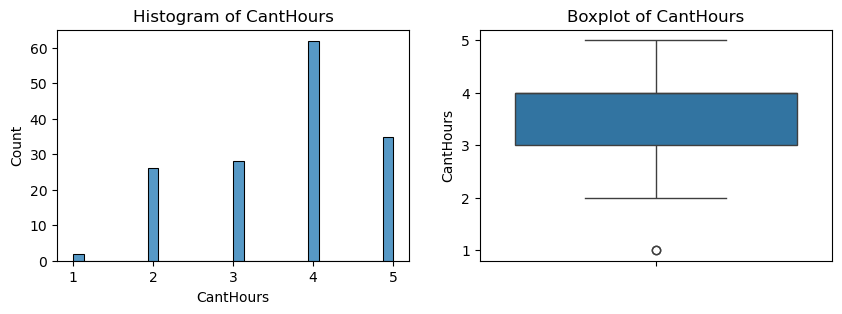

Skewness of CantHours: -0.4665959088297826
Kurtosis of CantHours: -0.7146220960790504


In [49]:
check_distribution_outliers(df[lik_col], lik_col)

# 6b. Encoding

Prepare for ordinal encoders

In [51]:
frq_ord = ["Beberapa kali dalam sehari", "Sehari sekali", "Beberapa kali dalam satu minggu", "Jarang atau tidak pernah"]
avg_ord = ["≤ Rp 15.000", "Rp 16.000 - Rp 20.000", "Rp 21.000 - Rp 25.000", "Rp 26.000 - Rp 30.000", "> Rp 30.000"]

In [53]:
encode_map = {
    "CanteenVisit": frq_ord,
    "AvgSpend": avg_ord
}

for col, order in encode_map.items():
    df[col] = pd.Categorical(df[col], categories=order, ordered=True).codes

In [ ]:
df